In [19]:
# Install required libraries
!pip install flask fastapi uvicorn scikit-learn numpy pandas python-multipart

# For Testing APIs
- Install Postman in your system
- Run server in your local machine
- Send requests from postman to server runnning on your local machine

# Alternate route
- Run server in your local machine
- Send requests from another terminal tab in your local machine to server runnning on your local machine. For this you will need to write a script in python using requests and json library.

In [20]:
# Import necessary libraries for Flask
import flask
from flask import Flask, request, jsonify
import numpy as np
import pandas as pd
import pickle
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

In [21]:
# Create a simple ML model to deploy
def create_model():
    # Load iris dataset
    iris = load_iris()
    X = iris.data
    y = iris.target

    # Train a simple RandomForest model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X, y)

    # Save model
    with open('rf_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    return model, iris.feature_names

# Create and save the model
model, feature_names = create_model()

In [22]:
# FLASK DEPLOYMENT ==============================================================


In [23]:
# Create Flask app
app = Flask(__name__)

In [10]:
# Load model for prediction
def load_model():
    with open('rf_model.pkl', 'rb') as f:
        model = pickle.load(f)
    return model

In [25]:
# Define prediction endpoint
@app.route('/predict', methods=['POST'])
def predict():
    # Get data from POST request
    data = request.get_json()

    # Check if data is in correct format
    if not data or 'features' not in data:
        return jsonify({'error': 'No valid features provided'}), 400

    # Convert data to numpy array for prediction
    try:
        features = np.array(data['features']).reshape(1, -1)
        model = load_model()
        prediction = model.predict(features).tolist()
        prediction_proba = model.predict_proba(features).tolist()

        return jsonify({
            'prediction': prediction,
            'probability': prediction_proba
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

In [ ]:
# Run Flask app
if __name__ == '__main__':
    app.run()

In [1]:
# Test our Flask API (Note: this will not work in actual execution since the Flask server needs to be running)
# This is just to demonstrate the request format
import requests
import json


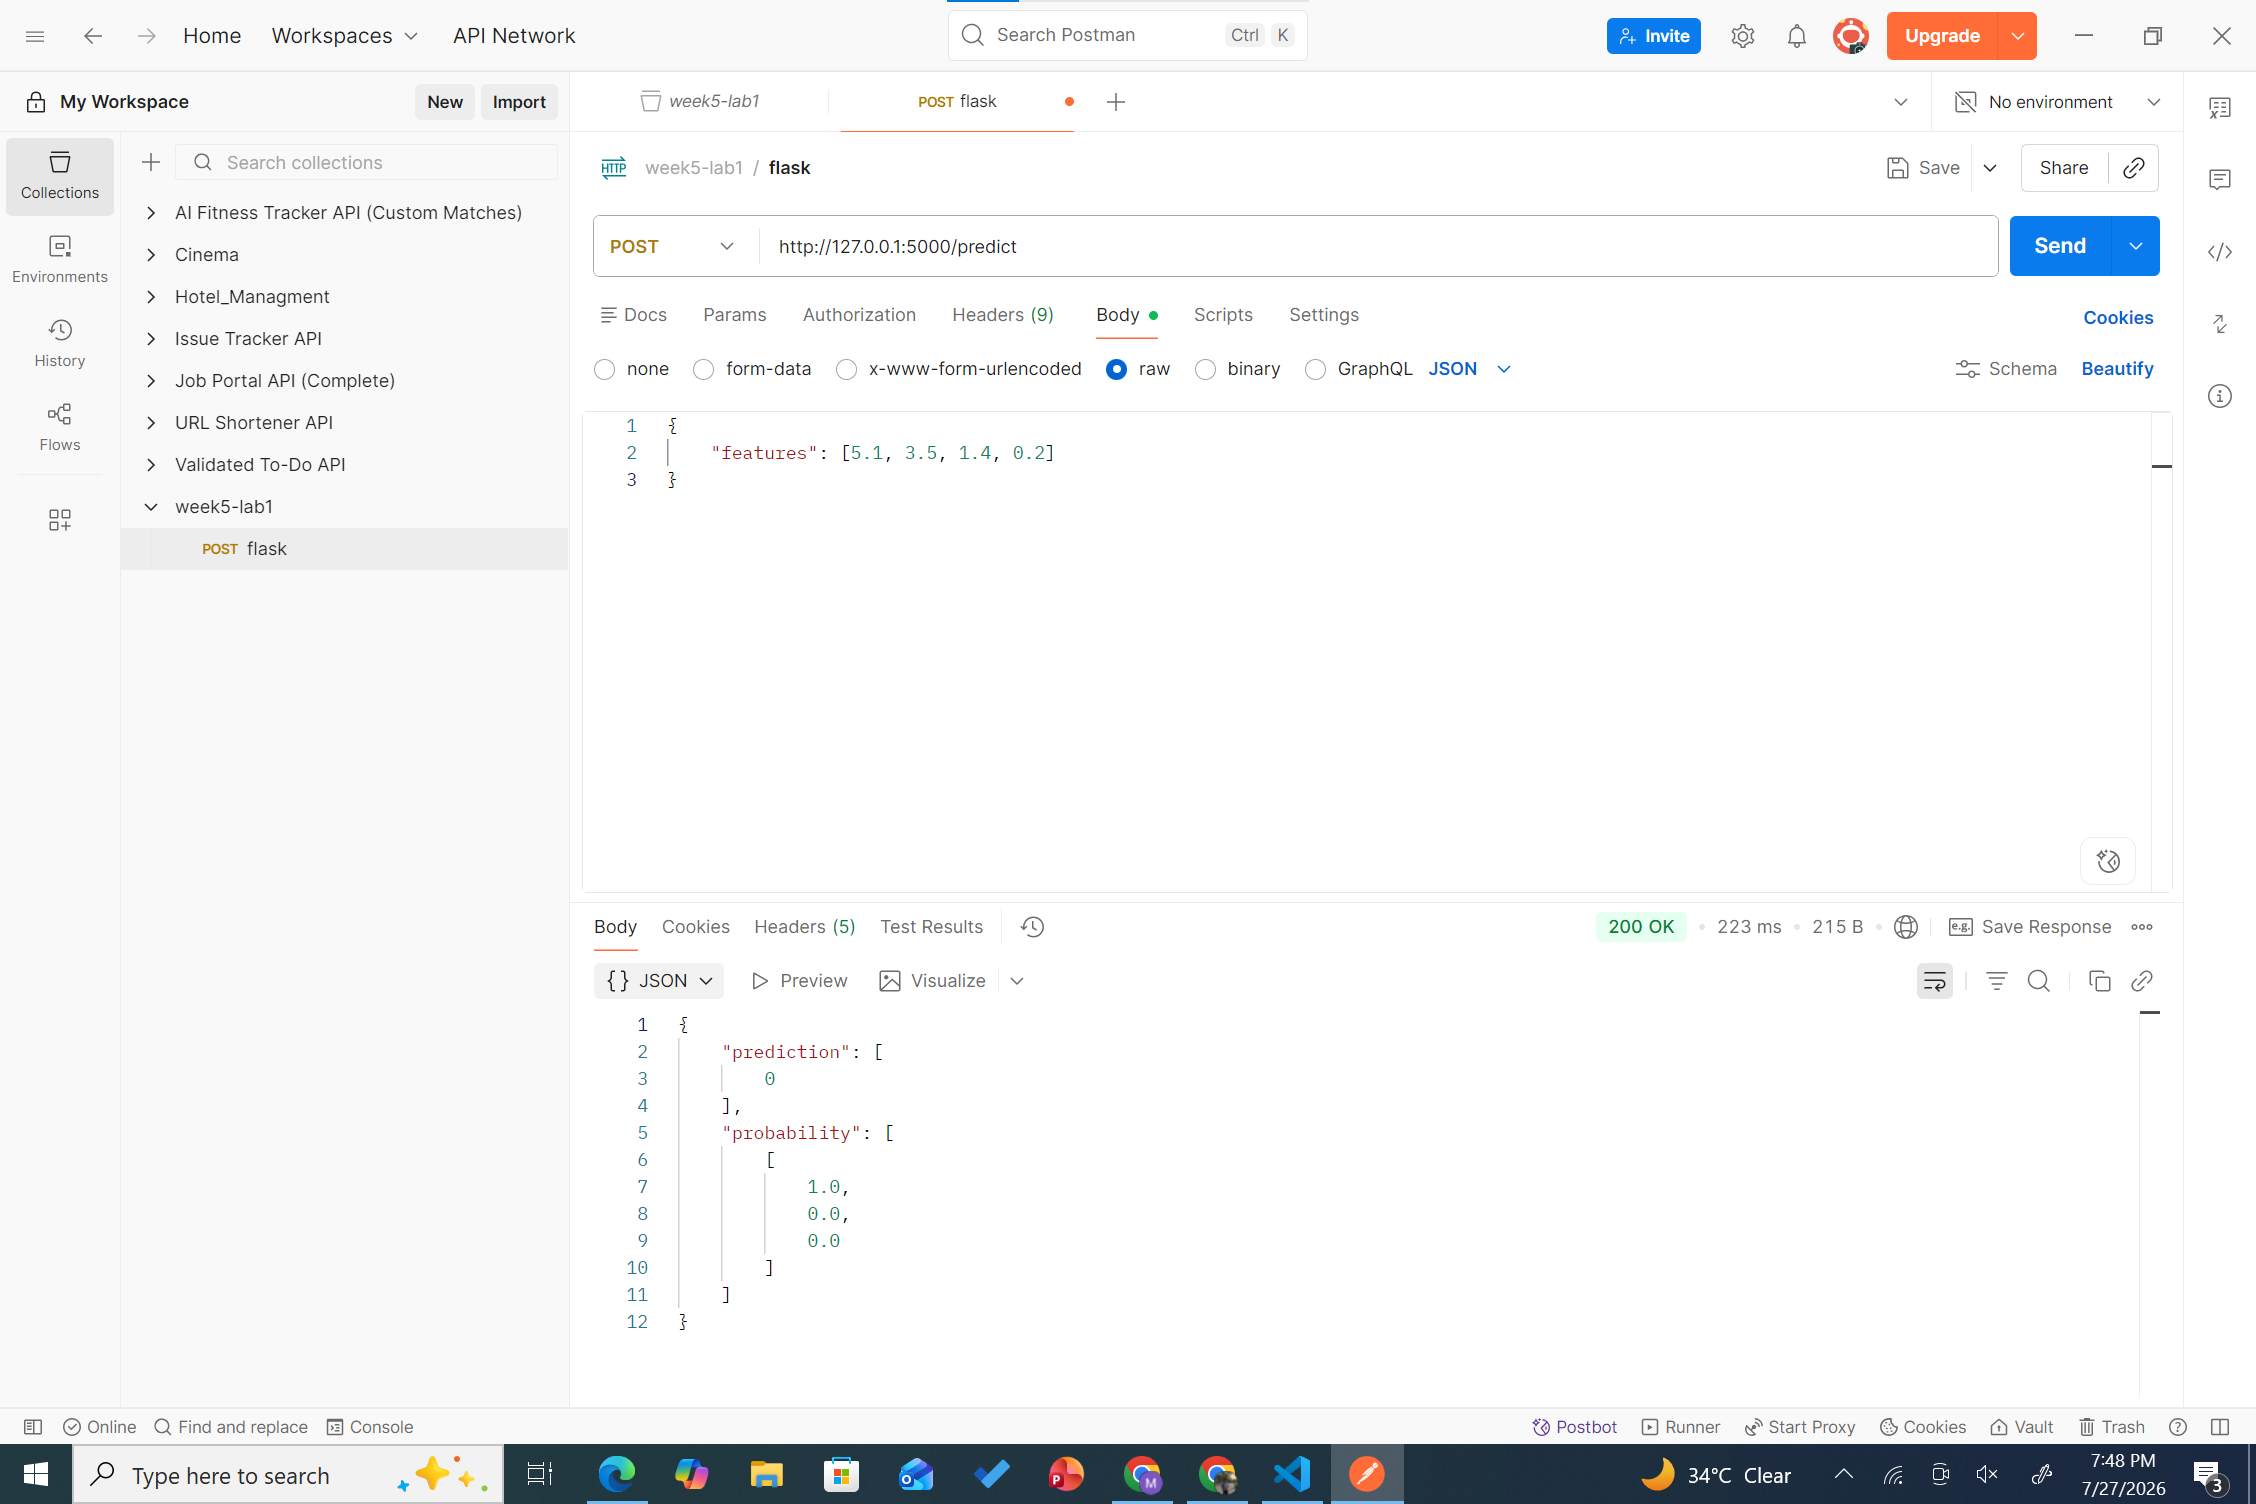

In [2]:
# Example features for Iris dataset (sepal length, sepal width, petal length, petal width)
example_features = [5.1, 3.5, 1.4, 0.2]  # Example of Iris setosa

In [ ]:
# The following would work if the Flask server was running

# response = requests.post('http://127.0.0.1:5000/predict',
#                         json={'features': example_features})
# print(response.json())


In [ ]:
# FASTAPI DEPLOYMENT ===========================================================


In [5]:

# Restart the notebook runtime before running this cell if you ran the Flask app

from fastapi import FastAPI, HTTPException, Body
from pydantic import BaseModel
import uvicorn
from typing import List, Dict, Any, Optional
import numpy as np
import pickle

In [6]:
# Define data model for API input
class IrisFeatures(BaseModel):
    features: List[float]

    class Config:
        schema_extra = {
            "example": {
                "features": [5.1, 3.5, 1.4, 0.2]
            }
        }


C:\Users\umairs\AppData\Local\Temp\ipykernel_1588\3646748506.py:2: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  class IrisFeatures(BaseModel):
c:\Users\umairs\ai-bootcamp\venv\lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [7]:
# Define data model for API output
class PredictionResponse(BaseModel):
    prediction: List[int]
    probability: List[List[float]]
    feature_importance: Optional[Dict[str, float]] = None


In [8]:
# Create FastAPI app
app_fastapi = FastAPI(
    title="Iris Classifier API",
    description="API for classifying iris flowers using a RandomForest model",
    version="1.0.0"
)


In [11]:
# Load the model at startup
model = load_model()

In [12]:
@app_fastapi.post("/predict", response_model=PredictionResponse)
async def predict_iris(iris_data: IrisFeatures):
    try:
        # Convert input features to numpy array
        features = np.array(iris_data.features).reshape(1, -1)

        # Make predictions
        prediction = model.predict(features).tolist()
        prediction_proba = model.predict_proba(features).tolist()

        # Get feature importance
        feature_importance = {}
        if hasattr(model, 'feature_importances_'):
            for i, importance in enumerate(model.feature_importances_):
                feature_name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
                feature_importance[feature_name] = float(importance)

        return {
            "prediction": prediction,
            "probability": prediction_proba,
            "feature_importance": feature_importance
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


In [15]:
# Health check endpoint
@app_fastapi.get("/health")
async def health_check():
    return {"status": "healthy"}


In [16]:

# Run FastAPI app
if __name__ == "__main__":
    uvicorn.run("app:app_fastapi", host="0.0.0.0", port=8000, reload=True)


INFO:     Will watch for changes in these directories: ['c:\\Users\\umairs\\ai-bootcamp\\week5-lab1']
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Started reloader process [1588] using StatReload
INFO:     Stopping reloader process [1588]


In [ ]:
# DEPLOY MODEL WITH BATCH PREDICTIONS IN FASTAPI ===============================


In [17]:
from fastapi import FastAPI, BackgroundTasks, File, UploadFile
import pandas as pd
import io
import asyncio
import time

In [18]:
# Create a new FastAPI app for batch processing
batch_app = FastAPI(title="Batch Prediction API")

In [19]:
# Queue to store batch jobs
job_queue = {}

In [20]:
# Function to process a batch job
async def process_batch_job(job_id: str, file_content: bytes):
    try:
        # Simulate processing delay
        await asyncio.sleep(2)

        # Read CSV content
        df = pd.read_csv(io.BytesIO(file_content))

        # Make predictions on batch data
        predictions = []
        for _, row in df.iterrows():
            # Extract the features from each row
            features = row.values.reshape(1, -1)
            pred = model.predict(features)[0]
            predictions.append(int(pred))

        # Update job status
        job_queue[job_id] = {
            "status": "completed",
            "predictions": predictions,
            "processed_at": time.strftime("%Y-%m-%d %H:%M:%S")
        }
    except Exception as e:
        job_queue[job_id] = {
            "status": "failed",
            "error": str(e),
            "processed_at": time.strftime("%Y-%m-%d %H:%M:%S")
        }


In [21]:
# Submit a batch job
@batch_app.post("/batch-predict")
async def create_batch_job(background_tasks: BackgroundTasks,
                           file: UploadFile = File(...)):
    try:
        # Generate a job ID
        job_id = f"job_{int(time.time())}"

        # Read file content
        file_content = await file.read()

        # Add job to queue with initial status
        job_queue[job_id] = {
            "status": "processing",
            "submitted_at": time.strftime("%Y-%m-%d %H:%M:%S")
        }

        # Start background task to process the job
        background_tasks.add_task(process_batch_job, job_id, file_content)

        return {"job_id": job_id, "status": "submitted"}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


In [22]:
# Check status of a batch job
@batch_app.get("/batch-status/{job_id}")
async def get_batch_status(job_id: str):
    if job_id not in job_queue:
        raise HTTPException(status_code=404, detail="Job not found")

    return job_queue[job_id]

In [23]:
# MODEL VERSIONING AND A/B TESTING IN FASTAPI =================================

from fastapi import Depends, Query
import random


In [24]:
# Create a versioned API app
version_app = FastAPI(title="Versioned Model API")


In [25]:
# Simulate multiple model versions
models = {
    "v1": model,  # Our original model
    "v2": model   # In real-world, this would be a different model version
}

In [26]:
# Model registry to track model metadata
model_registry = {
    "v1": {
        "version": "1.0.0",
        "created_at": "2023-01-01",
        "accuracy": 0.95,
        "training_data": "iris_dataset_2022"
    },
    "v2": {
        "version": "2.0.0",
        "created_at": "2023-06-01",
        "accuracy": 0.97,
        "training_data": "iris_dataset_2023"
    }
}

In [27]:
# Traffic allocation for A/B testing (70% to v1, 30% to v2)
model_weights = {"v1": 0.7, "v2": 0.3}


In [28]:
# Function to select model version based on weights
def get_model_version(ab_test: bool = Query(False, description="Enable A/B testing")):
    if ab_test:
        # Perform weighted random selection
        versions = list(model_weights.keys())
        weights = list(model_weights.values())
        selected_version = random.choices(versions, weights=weights, k=1)[0]
        return selected_version
    else:
        # Default to latest version
        return "v2"


In [29]:
# Predict endpoint with versioning
@version_app.post("/predict")
async def predict_with_version(
    iris_data: IrisFeatures,
    version: str = Query(None, description="Model version (v1 or v2)"),
    model_version: str = Depends(get_model_version)
):
    # Use specified version or the one from A/B testing
    selected_version = version if version else model_version

    if selected_version not in models:
        raise HTTPException(status_code=404, detail=f"Model version {selected_version} not found")

    selected_model = models[selected_version]

    # Convert input features to numpy array
    features = np.array(iris_data.features).reshape(1, -1)

    # Make predictions
    prediction = selected_model.predict(features).tolist()
    prediction_proba = selected_model.predict_proba(features).tolist()

    return {
        "prediction": prediction,
        "probability": prediction_proba,
        "model_version": selected_version,
        "model_info": model_registry[selected_version]
    }

In [30]:
# Get model registry information
@version_app.get("/models")
async def get_models():
    return model_registry

In [31]:
# MODEL MONITORING IN FASTAPI =================================================

from fastapi import BackgroundTasks
import time
import uuid
from datetime import datetime

# Create monitoring API app
monitoring_app = FastAPI(title="Model Monitoring API")

In [32]:
# Storage for prediction logs
prediction_logs = []

# Model performance metrics
model_metrics = {
    "total_requests": 0,
    "successful_predictions": 0,
    "failed_predictions": 0,
    "avg_response_time": 0,
    "prediction_distribution": {0: 0, 1: 0, 2: 0},
    "last_updated": None
}

In [33]:
# Log prediction for monitoring
async def log_prediction(features, prediction, response_time, success):
    global model_metrics

    # Update request counters
    model_metrics["total_requests"] += 1

    if success:
        model_metrics["successful_predictions"] += 1

        # Update prediction distribution
        pred_class = prediction[0]
        model_metrics["prediction_distribution"][pred_class] += 1
    else:
        model_metrics["failed_predictions"] += 1

    # Update average response time
    current_avg = model_metrics["avg_response_time"]
    model_metrics["avg_response_time"] = (current_avg * (model_metrics["total_requests"] - 1) +
                                         response_time) / model_metrics["total_requests"]

    # Update timestamp
    model_metrics["last_updated"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # Store detailed log
    prediction_logs.append({
        "id": str(uuid.uuid4()),
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "features": features,
        "prediction": prediction,
        "response_time": response_time,
        "success": success
    })

    # Keep only last 100 logs
    if len(prediction_logs) > 100:
        prediction_logs.pop(0)


In [36]:
# Prediction endpoint with monitoring
@monitoring_app.post("/predict")
async def predict_with_monitoring(iris_data: IrisFeatures, background_tasks: BackgroundTasks):
    start_time = time.time()
    success = True
    prediction = None

    try:
        # Convert input features to numpy array
        features = np.array(iris_data.features).reshape(1, -1)

        # Make predictions
        prediction = model.predict(features).tolist()
        prediction_proba = model.predict_proba(features).tolist()

        response = {
            "prediction": prediction,
            "probability": prediction_proba
        }
    except Exception as e:
     prediction if success else None,
    response_time,
    success
    

    return response

In [37]:
# Get monitoring metrics
@monitoring_app.get("/metrics")
async def get_metrics():
    return model_metrics

In [38]:
# Get recent prediction logs
@monitoring_app.get("/logs")
async def get_logs(limit: int = Query(10, ge=1, le=100)):
    return prediction_logs[-limit:]

In [49]:
# DEPLOY AN ENSEMBLE MODEL IN FASTAPI =========================================
from typing import Dict, List
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier


In [50]:
# Create ensemble models
def create_ensemble_models():
    # Load iris dataset
    iris = load_iris()
    X = iris.data
    y = iris.target

    # Train different models
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    lr_model = LogisticRegression(random_state=42)
    svm_model = SVC(probability=True, random_state=42)

    # Fit models
    rf_model.fit(X, y)
    lr_model.fit(X, y)
    svm_model.fit(X, y)

    # Save models
    ensemble = {
        "random_forest": rf_model,
        "logistic_regression": lr_model,
        "svm": svm_model
    }

    return ensemble, iris.feature_names

In [51]:
# Create ensemble
ensemble_models, _ = create_ensemble_models()

c:\Users\umairs\ai-bootcamp\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
# Create FastAPI app for ensemble
ensemble_app = FastAPI(title="Ensemble Model API")

# Define weights for each model
model_weights = {
    "random_forest": 0.5,
    "logistic_regression": 0.3,
    "svm": 0.2
}

In [53]:
# Predict using ensemble
@ensemble_app.post("/predict")
async def predict_ensemble(iris_data: IrisFeatures):
    # Convert input features to numpy array
    features = np.array(iris_data.features).reshape(1, -1)

    # Get predictions from each model
    predictions = {}
    probabilities = {}

    for model_name, model in ensemble_models.items():
        predictions[model_name] = model.predict(features)[0]
        probabilities[model_name] = model.predict_proba(features)[0].tolist()

    # Calculate weighted ensemble prediction
    ensemble_proba = np.zeros(3)  # 3 classes for Iris

    for model_name, proba in probabilities.items():
        weight = model_weights.get(model_name, 1/len(ensemble_models))
        ensemble_proba += weight * np.array(proba)

    # Get final prediction
    final_prediction = int(np.argmax(ensemble_proba))

    return {
        "ensemble_prediction": final_prediction,
        "ensemble_probability": ensemble_proba.tolist(),
        "individual_predictions": predictions,
        "individual_probabilities": probabilities
    }

In [54]:
# MODEL SERVING WITH CACHING IN FASTAPI =======================================

from fastapi import Depends, HTTPException, status
from fastapi.security import APIKeyHeader
import functools
import time

In [55]:
# Create a FastAPI app with caching and authentication
cache_app = FastAPI(title="Model API with Caching")

# Simple in-memory cache
prediction_cache = {}
CACHE_TTL = 300  # Time to live: 5 minutes


In [56]:
# API key auth
API_KEY = "your-secret-api-key"
api_key_header = APIKeyHeader(name="X-API-Key")

In [57]:
# Verify API key
def verify_api_key(api_key: str = Depends(api_key_header)):
    if api_key != API_KEY:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED,
            detail="Invalid API Key"
        )
    return api_key

In [58]:
# Cache decorator for predictions
def cache_prediction(ttl=CACHE_TTL):
    def decorator(func):
        @functools.wraps(func)
        async def wrapper(*args, **kwargs):
            # Create cache key from input features
            if 'iris_data' in kwargs:
                features_tuple = tuple(kwargs['iris_data'].features)
                cache_key = f"prediction_{features_tuple}"

                # Check if result is in cache and not expired
                if cache_key in prediction_cache:
                    result, timestamp = prediction_cache[cache_key]
                    if time.time() - timestamp < ttl:
                        return {**result, "cache_hit": True}

            # If not in cache or expired, compute result
            result = await func(*args, **kwargs)

            # Store result in cache
            if 'iris_data' in kwargs:
                prediction_cache[cache_key] = (result, time.time())

            return {**result, "cache_hit": False}
        return wrapper
    return decorator

In [59]:
# Predict with caching
@cache_app.post("/predict")
@cache_prediction(ttl=300)
async def predict_with_cache(
    iris_data: IrisFeatures,
    api_key: str = Depends(verify_api_key)
):
    # Convert input features to numpy array
    features = np.array(iris_data.features).reshape(1, -1)

    # Make predictions (simulating slow operation)
    time.sleep(1)  # Simulate processing time
    prediction = model.predict(features).tolist()
    prediction_proba = model.predict_proba(features).tolist()

    return {
        "prediction": prediction,
        "probability": prediction_proba,
    }


In [60]:
# Get cache statistics
@cache_app.get("/cache-info")
async def get_cache_info(api_key: str = Depends(verify_api_key)):
    current_time = time.time()
    active_cache_entries = sum(1 for _, (_, timestamp) in prediction_cache.items()
                              if current_time - timestamp < CACHE_TTL)

    return {
        "total_entries": len(prediction_cache),
        "active_entries": active_cache_entries,
        "cache_ttl": CACHE_TTL
    }

In [61]:
# Clear cache
@cache_app.post("/clear-cache")
async def clear_cache(api_key: str = Depends(verify_api_key)):
    prediction_cache.clear()
    return {"message": "Cache cleared successfully"}

# Excercise

In [ ]:
# EXERCISE: Build a Prediction API with Rate Limiting and Performance Metrics
# ----------------------------------------------------------------------------
# In this exercise, you will:
# 1. Create a FastAPI application that serves a machine learning model
# 2. Implement rate limiting to prevent API abuse
# 3. Add performance tracking to measure prediction latency
# 4. Implement a custom logging system to track model inputs and outputs
# 5. Create a dashboard endpoint to visualize model performance

In [ ]:
# SETUP: Run this cell first to prepare the exercise environment
!pip install fastapi uvicorn scikit-learn numpy pandas python-multipart

In [68]:
import numpy as np
import pandas as pd
from fastapi import FastAPI, Request, HTTPException, Depends
from fastapi.responses import JSONResponse
from pydantic import BaseModel
from typing import List, Dict, Any, Optional
import time
import uuid
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import pickle
import uvicorn

In [62]:
# Create a simple ML model for the exercise
iris = load_iris()
X = iris.data
y = iris.target
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
# Save model as a global variable for this exercise
iris_model = model
feature_names = iris.feature_names

# Define the input data model
class IrisFeatures(BaseModel):
    features: List[float]

    class Config:
        schema_extra = {
            "example": {
                "features": [5.1, 3.5, 1.4, 0.2]
            }
        }

C:\Users\umairs\AppData\Local\Temp\ipykernel_1588\598667344.py:6: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  class IrisFeatures(BaseModel):
c:\Users\umairs\ai-bootcamp\venv\lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)


In [ ]:
# YOUR TASK: Complete the following code to build the API with rate limiting and performance tracking

# PART 1: Create the FastAPI application with rate limiting
# ---------------------------------------------------------
# Implement a rate limiter that allows each client (identified by IP address)
# to make a maximum of 5 requests per minute

In [64]:
# TODO: Complete the code below to create a rate limiter
class RateLimiter:
    def __init__(self, requests_limit: int = 5, window_seconds: int = 60):
        # Initialize the rate limiter with empty request tracking
        self.requests_limit = requests_limit
        self.window_seconds = window_seconds
        self.request_history: Dict[str, List[float]] = {}

    def is_rate_limited(self, client_id: str) -> bool:
        # Check if the client has exceeded the rate limit
        current_time = time.time()
        timestamps = self.request_history.get(client_id, [])
        # Keep only requests that fall within the current time window
        timestamps = [t for t in timestamps if current_time - t < self.window_seconds]
        self.request_history[client_id] = timestamps
        return len(timestamps) >= self.requests_limit

    def add_request(self, client_id: str) -> None:
        # Record a new request for the client
        current_time = time.time()
        self.request_history.setdefault(client_id, []).append(current_time)

In [65]:
# Create the app and rate limiter
app = FastAPI(title="Iris Model API with Rate Limiting")
# Initialize the rate limiter
rate_limiter = RateLimiter(requests_limit=5, window_seconds=60)

In [69]:
# TODO: Implement the rate limiting dependency
async def check_rate_limit(request: Request):
    # Extract client IP or use a default for testing
    client_id = request.client.host if request.client else "test-client"

    # Check if client is rate limited
    if rate_limiter.is_rate_limited(client_id):
        # If limited, raise HTTPException
        raise HTTPException(
            status_code=429,
            detail="Rate limit exceeded. Maximum 5 requests per minute allowed."
        )

    # Record this request so it counts toward the limit
    rate_limiter.add_request(client_id)


In [ ]:
# PART 2: Implement performance tracking
# --------------------------------------
# Create a system to track prediction latency and model performance


In [70]:
# TODO: Complete the code below to track performance metrics
performance_metrics = {
    "total_requests": 0,
    "total_response_time": 0.0,
    "average_response_time": 0.0,
    "min_response_time": None,
    "max_response_time": None,
    "prediction_distribution": {0: 0, 1: 0, 2: 0},
    "last_updated": None
}

In [71]:
# TODO: Implement the function to update performance metrics
async def update_metrics(features, prediction, response_time):
    # Update the performance metrics with the new prediction data
    global performance_metrics

    performance_metrics["total_requests"] += 1
    performance_metrics["total_response_time"] += response_time
    performance_metrics["average_response_time"] = (
        performance_metrics["total_response_time"] / performance_metrics["total_requests"]
    )

    if performance_metrics["min_response_time"] is None or response_time < performance_metrics["min_response_time"]:
        performance_metrics["min_response_time"] = response_time
    if performance_metrics["max_response_time"] is None or response_time > performance_metrics["max_response_time"]:
        performance_metrics["max_response_time"] = response_time

    predicted_class = int(prediction[0]) if isinstance(prediction, list) else int(prediction)
    performance_metrics["prediction_distribution"][predicted_class] = (
        performance_metrics["prediction_distribution"].get(predicted_class, 0) + 1
    )

    performance_metrics["last_updated"] = datetime.now().isoformat()


In [72]:
# PART 3: Create the prediction endpoint
# --------------------------------------
# Implement the prediction endpoint with rate limiting and performance tracking

@app.post("/predict")
async def predict(iris_data: IrisFeatures, request: Request, rate_limit: None = Depends(check_rate_limit)):
    # 1. Record start time
    start_time = time.time()

    try:
        # 2. Make prediction
        features = np.array(iris_data.features).reshape(1, -1)
        prediction = iris_model.predict(features).tolist()
        prediction_proba = iris_model.predict_proba(features).tolist()

        # 3. Calculate response time
        response_time = time.time() - start_time

        # 4. Update metrics
        await update_metrics(iris_data.features, prediction, response_time)

        # 5. Return prediction response
        return {
            "prediction": prediction,
            "probability": prediction_proba,
            "response_time_seconds": response_time
        }
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


In [ ]:
# PART 4: Create a dashboard endpoint
# -----------------------------------
# Implement an endpoint to display performance metrics

import threading

@app.get("/dashboard")
async def dashboard():
    # Return a dashboard with performance metrics
    return {
        "performance_metrics": performance_metrics,
        "rate_limit_config": {
            "requests_limit": rate_limiter.requests_limit,
            "window_seconds": rate_limiter.window_seconds
        }
    }

# Run the application in a background thread so it doesn't block the notebook
# or collide with the kernel's own event loop
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

if __name__ == "__main__":
    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()

INFO:     Started server process [1588]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:64869 - "GET /docs HTTP/1.1" 200 OK
INFO:     127.0.0.1:64869 - "GET /openapi.json HTTP/1.1" 200 OK


c:\Users\umairs\ai-bootcamp\venv\lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
c:\Users\umairs\ai-bootcamp\venv\lib\site-packages\pydantic\_internal\_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
c:\Users\umairs\ai-bootcamp\venv\lib\site-packages\fastapi\openapi\utils.py:252: UserWarning: Duplicate Operation ID dashboard_dashboard_get for function dashboard
  warnings.warn(message, stacklevel=1)


INFO:     127.0.0.1:64966 - "GET / HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:64966 - "GET /favicon.ico HTTP/1.1" 404 Not Found


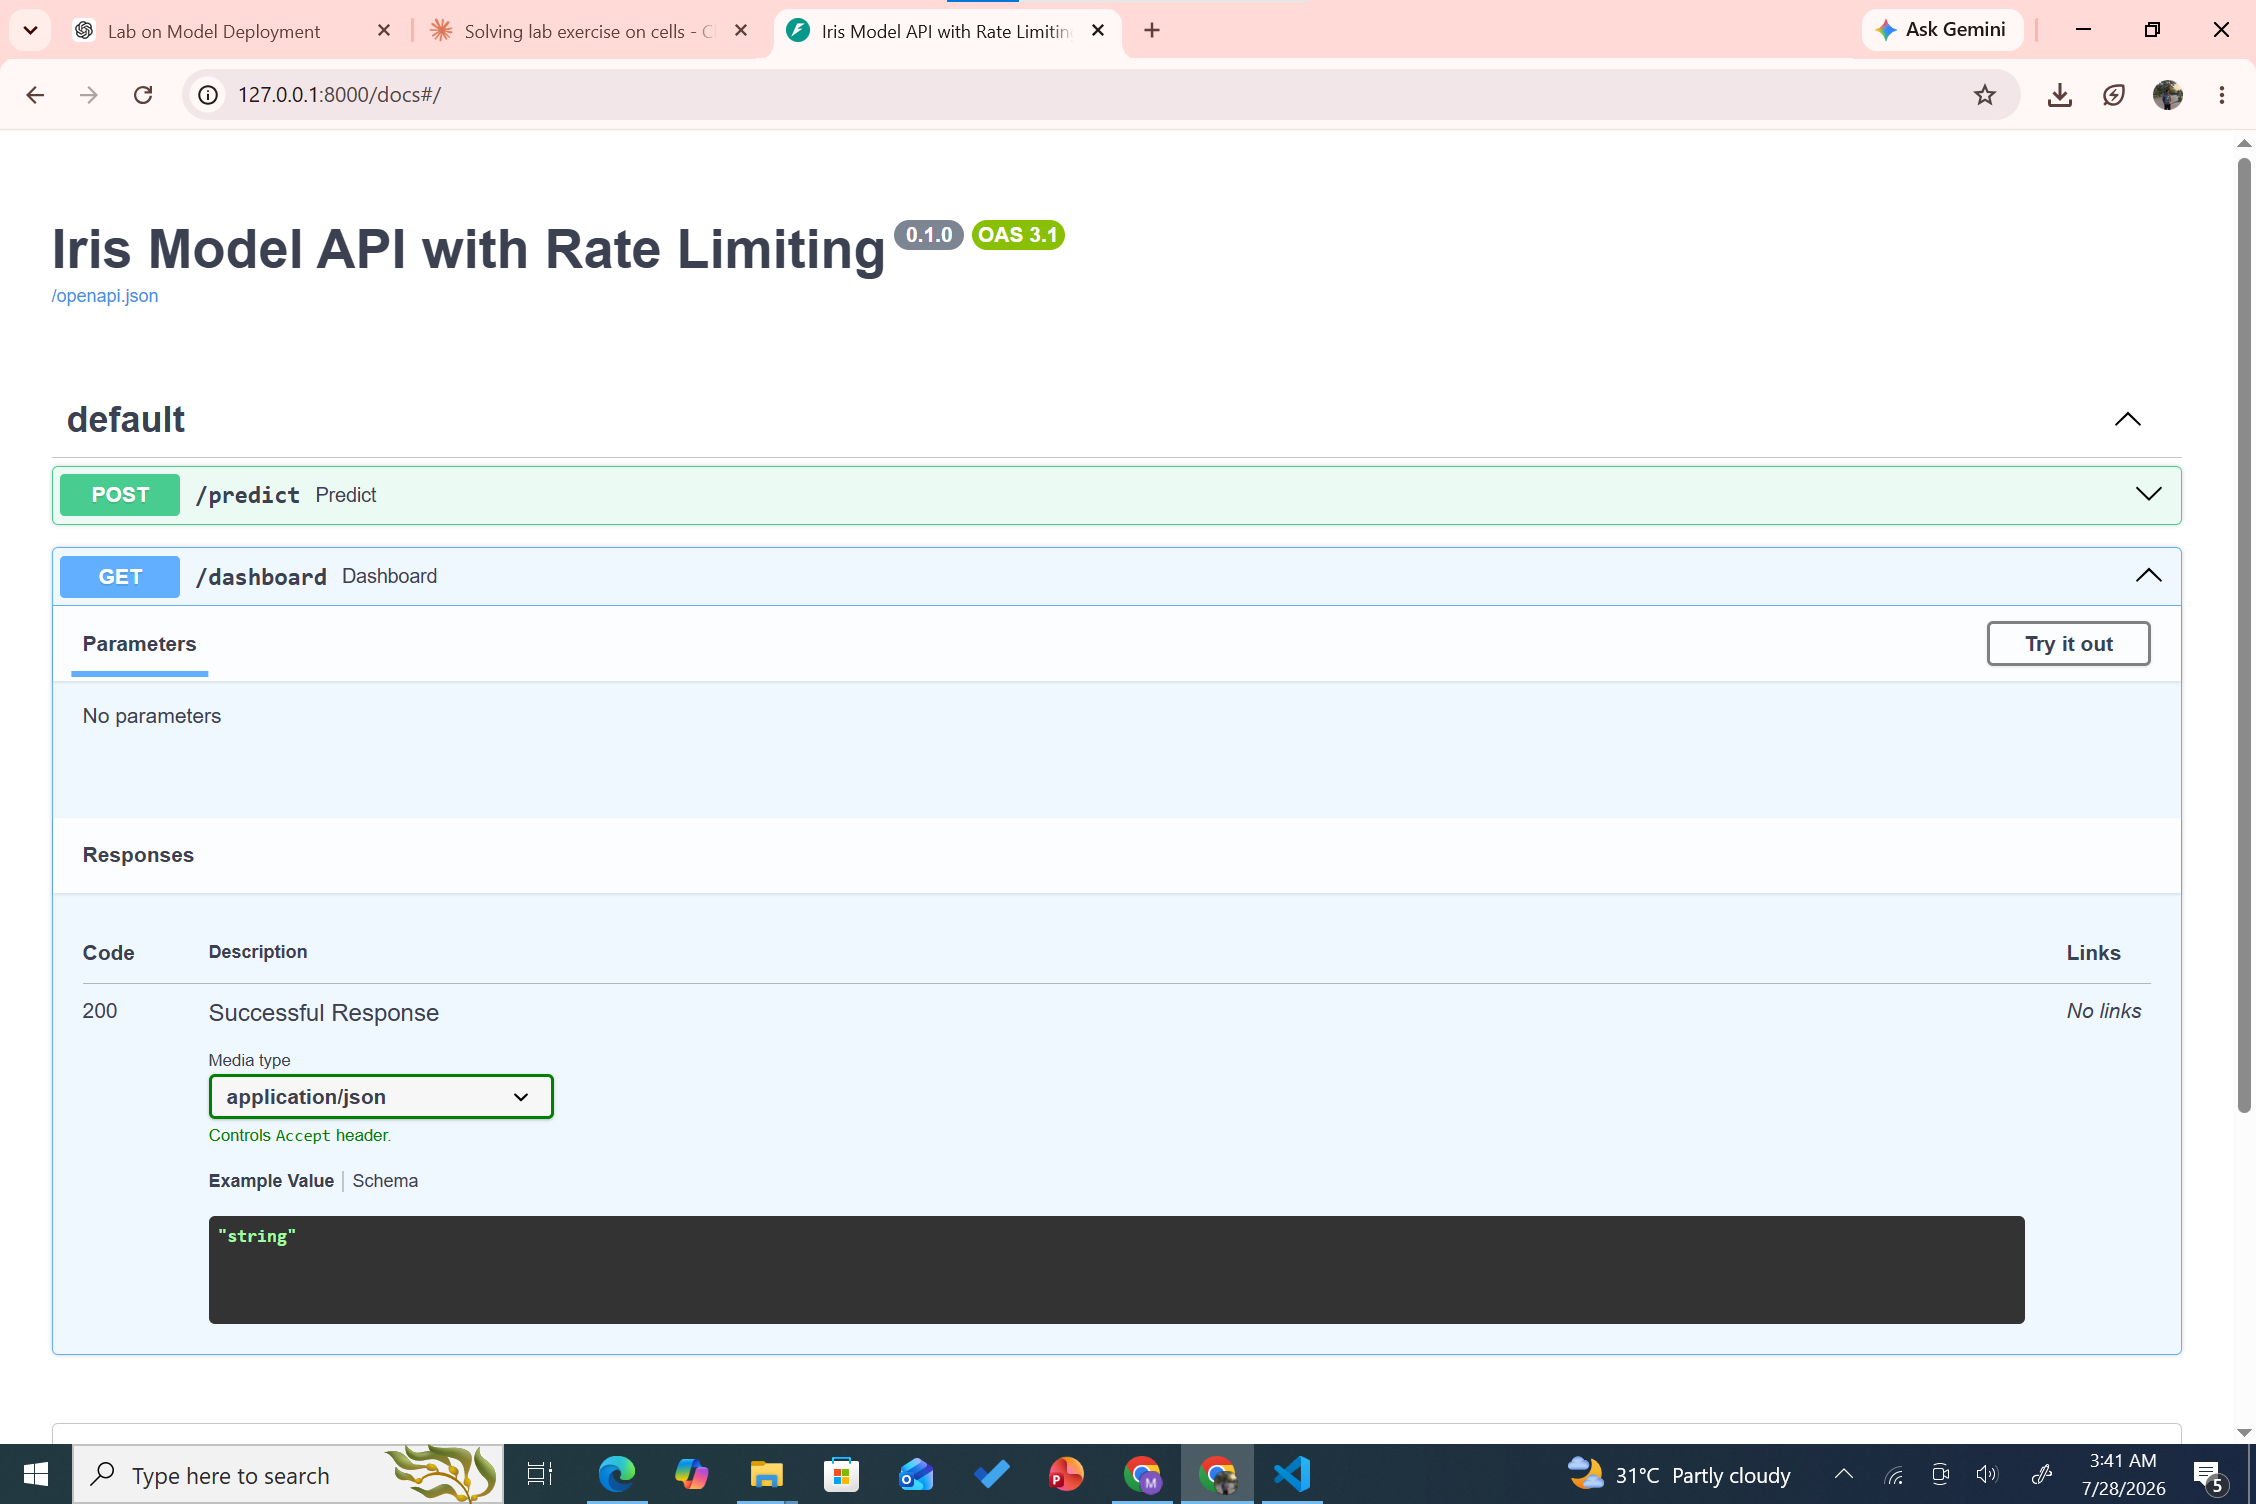